In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse
from src.utils import *

## X-RAY
from src.XRAY import xray_BJ

## W 
import pysptools.abundance_maps as amp
# nnls = amp.NNLS() # nonnegative constrained least squares and then row-normalize

In [2]:
%load_ext autoreload
%autoreload 2

# Read data

In [3]:
obj = load("data/CB_10locs_complete_nonegpm25mpm1_pmdiffsizebins.joblib")
df = obj["df"]
b = pd.to_numeric(df['bulldozer'], errors='coerce')
d = pd.to_numeric(df['downwind'],  errors='coerce')
df['bulldozerxdownwind'] = (b*d).astype('Int8')
ys1 = ['pm1', 'tspmpm1', 'bc', 'co', 'no', 'no2']
Y1 = obj["Y"][ys1]
ys2 = ['pm25', 'tspmpm25', 'bc', 'co', 'no', 'no2']
Y25 = obj["Y"][ys2]
col_label1 = ["PM1", "TSP-PM1", "BC", "CO", "NO", "NO2"]
col_label2 = ["PM2.5", "TSP-PM2.5", "BC", "CO", "NO", "NO2"]
colors1 = ["tab:blue", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]
colors2 = ["tab:orange", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

In [4]:
seed = 910
K_list = [3, 4, 5]

# path 
outdir = Path("results/CB")
outdir.mkdir(parents=True, exist_ok=True)

# PM2.5 and TSP-PM2.5

In [ ]:
# # sourceXray
# results = {}

# ## K = 3
# K = 3
# seed_K = seed+K
    
# start = time.time()
# H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y25, K, seed=seed_K, prune=False, verbose=True)[0]
# end = time.time()
# time_sourceXray = end - start

# results[K] = {
#     "time": time_sourceXray,
#     "H_star": H_star_hat,
#     "W_tilde": W_tilde_hat, 
#     "mu_tilde": mu_tilde_hat, 
#     "C": C_hat, 
#     "logvol": logvol_hat
# }

# # save
# dump(results[K], outdir/f"sourceXray_CB_nonegpm25mpm1_pm25_tspmpm25_K{K}.joblib")
    
# ## K = 4
# K = 4
# seed_K = seed+K
    
# start = time.time()
# H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y25, K, seed=seed_K, prune=True, min_K=50*K, verbose=True)[0]
# end = time.time()
# time_sourceXray = end - start

# results[K] = {
#     "time": time_sourceXray,
#     "H_star": H_star_hat,
#     "W_tilde": W_tilde_hat, 
#     "mu_tilde": mu_tilde_hat, 
#     "C": C_hat, 
#     "logvol": logvol_hat
# }

# # save
# dump(results[K], outdir/f"sourceXray_CB_nonegpm25mpm1_pm25_tspmpm25_K{K}_minK{50*K}.joblib")

# ## K = 5
# K = 5
# seed_K = seed+K
    
# start = time.time()
# H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y25, K, seed=seed_K, prune=True, min_K=20*K, verbose=True)[0]
# end = time.time()
# time_sourceXray = end - start

# results[K] = {
#     "time": time_sourceXray,
#     "H_star": H_star_hat,
#     "W_tilde": W_tilde_hat, 
#     "mu_tilde": mu_tilde_hat, 
#     "C": C_hat, 
#     "logvol": logvol_hat
# }

# # save
# dump(results[K], outdir/f"sourceXray_CB_nonegpm25mpm1_pm25_tspmpm25_K{K}_minK{20*K}.joblib")

# # save for all K
# dump(results, outdir/f"sourceXray_CB_nonegpm25mpm1_pm25_tspmpm25_allK.joblib")

In [6]:
results = load(outdir/f"sourceXray_CB_nonegpm25mpm1_pm25_tspmpm25_allK.joblib")

In [7]:
# volume
print(np.exp(results[3]["logvol"]))
print(np.exp(results[4]["logvol"]))
print(np.exp(results[5]["logvol"]))

0.720577941954572
0.22039603286994933
0.042217089283839375


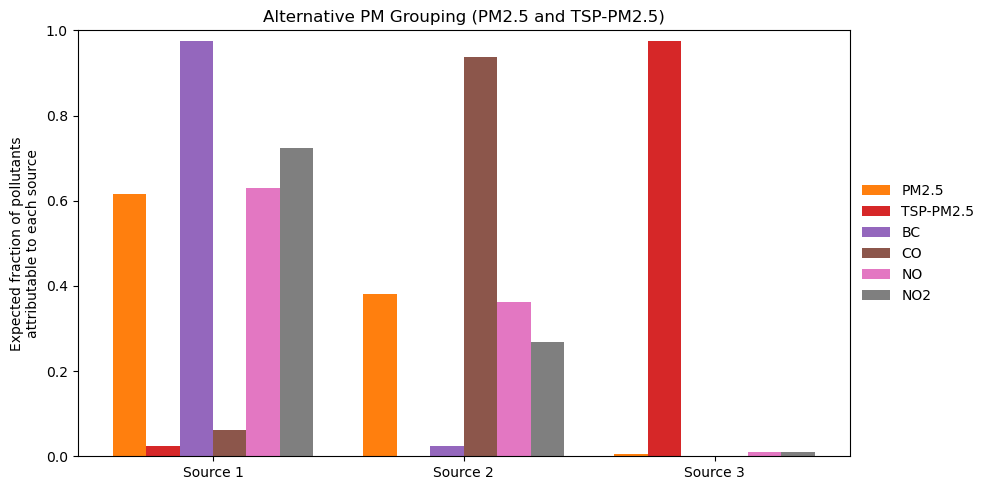

In [ ]:
plot_C_matrix_grouped_by_k(results[3]["C"][:,[1,0,2]], 
                           title="Alternative PM Grouping (PM2.5 and TSP-PM2.5)", 
                           col_label=col_label2, colors=colors2, 
                           # savepath="results/CB/figure/CB_nonegpm25mpm1_sourceXray_pm25_tspmpm25_K3_Phi.pdf"
                        )

## Diurnal pattern of source intensity

In [9]:
K = 3
ss = [f"Source {i+1}" for i in range(K)]
W_df = pd.DataFrame(results[K]["W_tilde"][:,[1,0,2]], columns=ss)
W_df = pd.concat([df[["date_local", "location", "bulldozer"]], 
                  W_df.reset_index(drop=True)], axis=1)

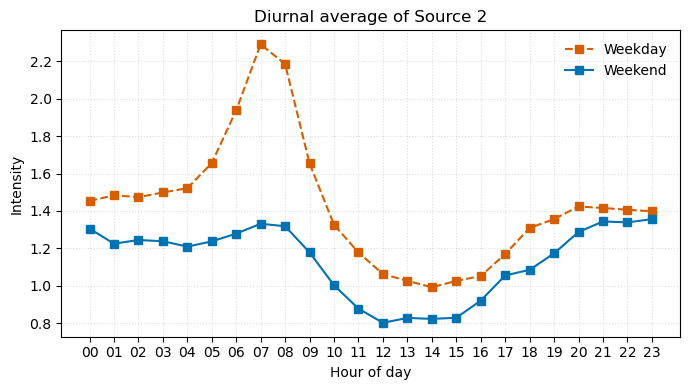

In [ ]:
week = np.where(W_df['date_local'].dt.dayofweek >= 5, 'Weekend', 'Weekday') # Sat=5, Sun=6
k = 'Source 2'
plot_diurnal_W(W = W_df, 
               columnidx=W_df.columns.get_loc(k),
               timestamps = W_df['date_local'], 
               covariate=week, 
               agg="mean", 
               quantiles=None,
               figsize=(7,4),
               legend_title=None,
               title=f"Diurnal average of {k}", 
               ylabel="Intensity", 
               color_map={"Weekend": "#0072B2", "Weekday": "#D55E00"},
               linestyle_map={"Weekend": "-", "Weekday": "--"},
               point_map={"Weekend": "s", "Weekday": "s"},   
               # savepath="results/CB/figure/CB_nonegpm25mpm1_pm25_tspmpm25_K3_traffic_source_diurnal.pdf"
)

## Regression

In [11]:
# Responses and formula for multiple regressions
formula = (
    "bulldozer*downwind + temp + no + windspeed + am + solar + location"
)

In [13]:
## attach W as columns "Sourcek" to df
df25 = pd.concat([df, pd.DataFrame(results[K]["W_tilde"][:,[1,0,2]], columns=[f"Source{i+1}" for i in range(K)])], axis=1)

In [14]:
## run regressions
coef_ss = run_multireg(df = df25, ys = [f"Source{i+1}" for i in range(K)], formula_rhs = formula, save_all=True, add_main_plus=True)
# coef_ss

/Users/borajin/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


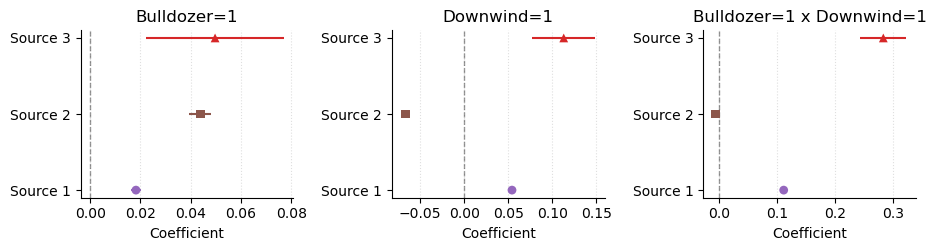

In [ ]:
source_labels = {f"Source{k}": f"Source {k}" for k in range(1, K+1)}
ordered_x_subset = ['bulldozer[T.1]', 'downwind[T.1]', 'main_plus_interaction']
coef_ss_plot = (coef_ss
    .query("term in @ordered_x_subset")
    .rename(columns={'ci_low': 'lo', 'ci_high': 'hi'})
)
def pretty_x(t):
    mapping = {
        "main_plus_interaction": "Bulldozer=1 x Downwind=1",
        "bulldozer[T.1]": "Bulldozer=1",
        "downwind[T.1]":  "Downwind=1",
    }
    return mapping.get(t, t)
coef_ss_plot["label_y"] = coef_ss_plot["response"].map(lambda s: source_labels.get(s, s))
coef_ss_plot["label_x"] = coef_ss_plot["term"].map(pretty_x)

plot_coefficients_by_response(
    coef_ss_plot, 
    color_map = {"Source1": "tab:purple", "Source2": "tab:brown", "Source3": "tab:red"}, 
    # savepath = "results/CB/figure/CB_nonegpm25mpm1_pm25_tspmpm25_K3_lm_coefs_W.pdf"
)